In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
df = pd.read_csv('data/03_telco_transformed.csv')

# **Predictive Modelling**

## **Introduction**

<small>**In this section, I will be utilising machine learning algorithms to analyse historical data and forecast future outcomes for the Telcom company. In a business context, customer retention is often critical to maintaining profitability. By predicting which customers are at risk of leaving (churning), companies can take proactive measures to improve retention strategies.**

## **1. Context of Data**

<small>This dataset **(03_telco_transformed.csv)** contains records of individual telecommunications customer accounts. It presents a **classic binary classification problem**, where the goal is to predict a distinct two-class outcome: whether a customer will churn or remain with the service. 

**Target variable:** Churn, serves as the primary focal point, using a binary label where 0 represents an active customer and 1 indicates a customer who has left.


**Sample Size:** 7,032 records (customer accounts) across 23 total features (columns).

In [19]:
#Verify the shape of the dataset
print(df.shape)
print("The number of rows in the dataset is: ", df.shape[0])
print("The number of columns in the dataset is: ", df.shape[1])

(7032, 23)
The number of rows in the dataset is:  7032
The number of columns in the dataset is:  23


In [20]:
#Check the column names in the dataset
print(df.columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'Churn',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_Yes', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes',
       'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year',
       'Contract_Two year'],
      dtype='str')


## **2. The Transformed Data**

<small> The raw dataset has undergone pre-processing and feature transformation to prepare it for machine learning algorithms.

Here is the transformation carried out in the previous sections:

1. **Missing Values Removal:** During the Data Cleaning stage, rows with incomplete profiles were handled, leaving 7,032 complete records. 

2. **No Categorical Strings Remaining:** All features are encoded as integer flags (0 or 1) or continuous numeric values (float64 / int64).

3. **Numeric Encoding:** Categorical text fields (e.g., payment methods, contract types, internet service options) have been converted into binary indicator variables (One-Hot Encoding).

## **3. Selecting the Models to be Tested**

### **A. Logistic Regression**

<small>**In the context of the Telco dataset analyzed earlier, predicting whether a customer will churn (1) or remain (0) is a classic binomial classification task which is why Logistic Regression serves as an effective linear baseline model**

<small> Contrary to linear regression, which predicts continuous values it predicts the probability that an input belongs to a specific class.

Logistic Regression is applied to binary classification where the output can be either of two possible categories such as Yes/No, True/False or 0/1.

The sigmoid function is used to convert inputs into a probability value between 0 and 1.

#### **Assumptions**

<small>

1. Binary OutcomeThe Rule: The target variable must be binary (two categories) for standard binomial logistic regression.

2. Each data point (customer record) must be statistically independent of every other data point.

3. Continuous independent variables (tenure and MonthlyCharges) must have a linear relationship with the log-odds (logit) of the target variable, not directly with the probability itself.

4. Predictor features should not be highly correlated with one another (TotalCharges was dropped earlier due to this)

5. Sufficiently Large Sample Size (Our dataset had 7,032 records which satisfies this assumption)

#### **Mathematical Framework**



Logistic regression models the probability of churn $P(Y = 1 \mid \mathbf{X})$ through three mathematical stages:

1. **The Logit Link (Log-Odds Equation):**
   $$z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p$$

2. **The Sigmoid / Logistic Function:**
   $$\hat{p} = P(\text{Churn} = 1 \mid \mathbf{X}) = \frac{1}{1 + e^{-z}}$$

3. **The Binary Decision Threshold (Binomial Output):**
   $$\hat{Y} = \begin{cases} 1 & \text{if } \hat{p} \ge 0.5 \quad (\text{Customer Churns}) \\ 0 & \text{if } \hat{p} < 0.5 \quad (\text{Customer Retained}) \end{cases}$$

### **Applying Logistic Regression on the dataset**

##### **Step 1: Isolating the Target Variable (Churn)**

<small> **I will begin by importing the relevant libraries, and then separate the predictors/independant (X) variables from the target variable (y, Churn). This is because machine learning algorithms require a clear distinction between the inputs (features) and the output (target) during training.**

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, classification_report
)



# Separate features (X) and target (y)
# Dropping Churn from your features to create your clean matrix (X)
X = df.drop(columns=['Churn'])

#Removing the churn by itself for modelling purposes
# Isolating my target variable (y)

y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

#Now X has exactly 22 columns, y is the 1D target array, and is ready for modelling!

Features shape: (7032, 22)
Target distribution:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


##### **Step 2: Split Data into Train and Test Sets**

In [22]:
# Splitting data into 80% train and 20% test
# 'stratify=y' ensures balanced proportions of churn in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"\nTraining target balance:\n{y_train.value_counts(normalize=True)}")
print(f"\nTesting target balance:\n{y_test.value_counts(normalize=True)}")

Training set: 5625 samples
Testing set:  1407 samples
Training features shape: (5625, 22)
Testing features shape: (1407, 22)

Training target balance:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing target balance:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


##### **Step 3: Feature Scaling (Standardisation)**

<small> We have two continuous variables: **tenure** and **MonthlyCharges** with much larger scales. Tenure ranges from 1 to 72 months while MonthlyCharges are listed $18 to $118 (Refer to chart plotted in 03_data_transformation.ipynb). I will apply scaling which should ensure stable gradient convergence.

In [23]:
# Initialising and fitting the scaler
scaler = StandardScaler()

# Transforming  features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Continuous features have been scaled successfully!")

Continuous features have been scaled successfully!


In [24]:
#Redefining the dataframes with the scaled values and the original column names for better interpretability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled_df.to_csv('data/modelling_data/X_train_scaled.csv', index=False)
X_test_scaled_df.to_csv('data/modelling_data/X_test_scaled.csv', index=False)
y_train.to_csv('data/modelling_data/y_train.csv', index=False)
y_test.to_csv('data/modelling_data/y_test.csv', index=False)

##### **Step 4: Model Instantiation and Training**

In [25]:
#Here, I will be instantiating LogisticRegression and fitting it using the scaled training features.
#We use class_weight='balanced' to handle the 73/27 data split perfectly.
log_reg = LogisticRegression(  max_iter=1000, random_state=42)

# Fitting model on training data
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


##### **Step 5: Model Predictions and Probabilities**

<small> Generating both discrete class prediction and predicted probabilities

In [26]:
# Predict discrete classes (0 or 1) using default 0.5 threshold
y_pred = log_reg.predict(X_test_scaled)

# Predict probabilities for the positive class (Churn = 1)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Display first 5 test samples with probabilities
preview = pd.DataFrame({
    'Actual': y_test.iloc[:5].values,
    'Predicted_Class': y_pred[:5],
    'Churn_Probability': np.round(y_proba[:5], 4)
})
print(preview)

   Actual  Predicted_Class  Churn_Probability
0       0                0             0.0188
1       0                1             0.6053
2       0                0             0.0101
3       1                0             0.1792
4       0                0             0.0769


##### **Step 6: Model Evaluation Metrics**

<small> Evaluating a classification model requires looking beyond raw accuracy, especially when dealing with imbalanced datasets like customer churn (where retained customers far outnumber churners). To assess overall predictive performance and real-world applicability, five primary metrics are calculated on the unseen test dataset: Accuracy, Precision, Recall, F1-Score and ROC-AUC

In [27]:
# Calculating core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}\n")

# Detailed Classification Report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

Accuracy:  0.8038
Precision: 0.6485
Recall:    0.5722
F1-Score:  0.6080
ROC-AUC:   0.8332

Detailed Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.85      0.89      0.87      1033
 Churned (1)       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



<small> **Accuracy (80.38%):**
 The model correctly classifies approximately 4 out of every 5 customer profiles, achieving 1,131 correct predictions out of 1,407 test samples. This high overall correctness confirms that the model has learned meaningful underlying patterns rather than simply guessing.

**Precision (64.85%):** Out of every 100 customers the model flags as high-risk churners, approximately 65 actually churn. This moderate-to-high precision score ensures that retention campaigns and promotional discounts are targeted efficiently without excessive waste on loyal subscribers.

**Recall / Sensitivity (57.22%):** Out of 374 actual churners in the test set, the model successfully catches 214 of them. While catching nearly 60% of at-risk accounts, 160 churners slip through undetected under the default 0.50 probability threshold.

**F1-Score (0.6080):** The harmonic mean between precision and recall indicates a balanced operational baseline, providing a single metric to benchmark against future model iterations.

**ROC-AUC (0.8332):** Reflecting an 83.32% ability to rank risk probabilities correctly, this high score demonstrates that the model reliably assigns higher churn probabilities to customers who actually leave compared to those who stay, regardless of the decision threshold used.




Visualising the Evaluation Metrics for Logistic Regression Model

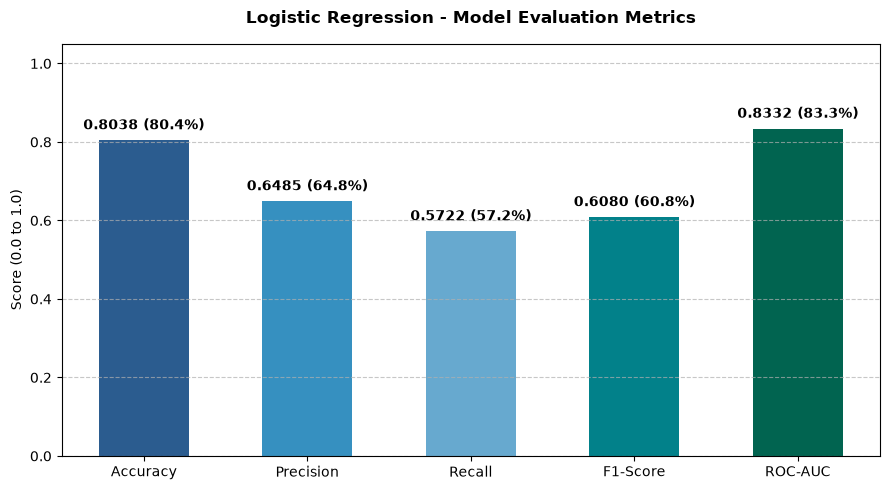

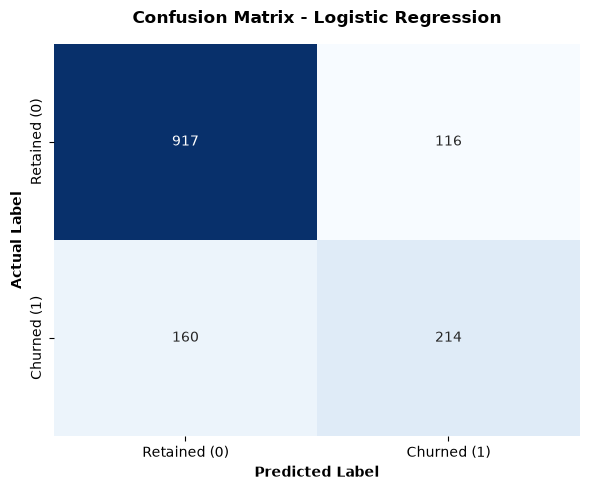

In [28]:
#2. Plot Chart 1: Evaluation Metrics Bar Chart
metrics_data = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': auc
}

plt.figure(figsize=(9, 5))
palette = ['#2b5c8f', '#3690c0', '#67a9cf', '#02818a', '#016450']
bars = plt.bar(metrics_data.keys(), metrics_data.values(), color=palette, width=0.55)

plt.ylim(0, 1.05)
plt.ylabel('Score (0.0 to 1.0)')
plt.title('Logistic Regression - Model Evaluation Metrics', fontweight='bold', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + 0.02,
        f'{height:.4f} ({height*100:.1f}%)',
        ha='center', va='bottom', fontweight='bold'
    )

plt.tight_layout()
plt.show()

# 3. Plot Chart 2: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retained (0)', 'Churned (1)'],
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('Actual Label', fontweight='bold')
plt.title('Confusion Matrix - Logistic Regression', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

##### **Step 7: Confusion Matrix**

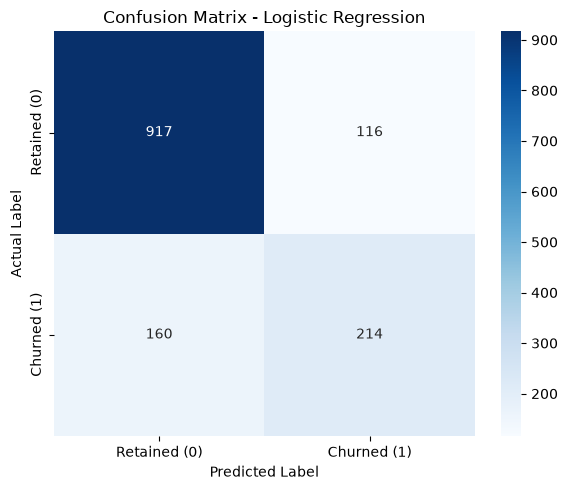

In [29]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained (0)', 'Churned (1)'],
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

In [30]:
# Extract feature coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Beta)': log_reg.coef_[0],
    'Odds Ratio': np.exp(log_reg.coef_[0])  # e^(beta)
}).sort_values(by='Coefficient (Beta)', ascending=False)

print("Top Predictors Increasing Churn Risk (Positive Coefficients):")
print(coefficients.head(5).to_string(index=False))

print("\nTop Predictors Reducing Churn Risk (Negative Coefficients):")
print(coefficients.tail(5).to_string(index=False))

Top Predictors Increasing Churn Risk (Positive Coefficients):
                       Feature  Coefficient (Beta)  Odds Ratio
   InternetService_Fiber optic            0.731527    2.078251
               StreamingTV_Yes            0.257869    1.294169
           StreamingMovies_Yes            0.245422    1.278161
             MultipleLines_Yes            0.223821    1.250847
PaymentMethod_Electronic check            0.187925    1.206743

Top Predictors Reducing Churn Risk (Negative Coefficients):
           Feature  Coefficient (Beta)  Odds Ratio
 Contract_One year           -0.309389    0.733896
InternetService_No           -0.568343    0.566464
 Contract_Two year           -0.590375    0.554119
    MonthlyCharges           -0.687091    0.503037
            tenure           -0.802280    0.448305
